In [ ]:
import sys

# Проверяем, запущен ли ноутбук в среде Google Colab
if "google.colab" in sys.modules:
    !pip install uv -q
    !wget https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/pyproject.toml -q
    !uv pip install -r pyproject.toml --system -q

# Семинар 1 · Ноутбук 3
# Интервалы прогнозирования и оценка их качества

Точечный прогноз $\hat y_{n+h|n}$ — это, как правило, **среднее** условного распределения
$y_{n+h}\mid y_1,\dots,y_n$. Но одно число не говорит, насколько мы уверены. **Интервал
прогноза** (prediction interval, PI) задаёт диапазон, в котором будущее значение окажется
с заданной вероятностью.

Лекция подчёркивает: *точечные прогнозы часто бесполезны без интервалов*. В этом ноутбуке мы:

- разберём PI **в предположении нормальности** остатков: $\hat y \pm z_{1-\alpha/2}\,\hat\sigma_h$;
- выведем **аналитические формулы** дисперсии для четырёх базовых методов и увидим, как
  интервал расширяется с горизонтом $h$;
- научимся **оценивать качество** интервальных прогнозов: Coverage Rate, Mean Interval Width,
  Winkler Score, Quantile Score (pinball loss) и CRPS;
- построим PI **из коробки** и посчитаем те же метрики в трёх фреймворках — `statsforecast`,
  `sktime` и `etna` — и разберём, как именно каждый из них считает границы внутри.

🔍 Чего сегодня **не** будет: бутстреп-интервалов и конформного прогнозирования. Это отдельные
способы построить PI без предположения нормальности — им посвящено отдельное занятие. Здесь
лишь укажем, где их искать в API каждого фреймворка (последний раздел ноутбука).

> **Требуются библиотеки:** `numpy`, `pandas`, `matplotlib`, `scipy`, `statsforecast`,
> `utilsforecast`, `sktime`, `etna`. Данные — `https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/data/jj.csv` (тот же ряд, что в ноутбуке 1:
> квартальная прибыль на акцию Johnson & Johnson, $m=4$).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

plt.rcParams["figure.figsize"] = (14, 5)

---
# 0. Данные и постановка задачи

## 0.1. Загрузка ряда и train/test-разбиение

Берём тот же ряд, что и в ноутбуке 1: квартальная прибыль на акцию J&J. Как и там, округляем
даты до начала квартала — иначе фреймворки в разделе 3 будут строить свою регулярную сетку дат
и молча потеряют точки при склейке с фактическими значениями (подробности — в ноутбуке 1, §0.1).

In [2]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/alex-hse-repository/time-series-cu-2026/refs/heads/main/week_2/data/jj.csv"
)
df["date"] = pd.to_datetime(df["date"]).dt.to_period("Q").dt.start_time
df.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-01,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


В ноутбуке 1 для точечных прогнозов хватало теста из 4 кварталов. Для интервалов этого мало:
**Coverage Rate** — это доля точек, попавших в интервал, и на 4 наблюдениях она может принимать
только значения $0\%, 25\%, 50\%, 75\%, 100\%$ — шаг слишком грубый, чтобы отличить хороший
интервал от плохого. Возьмём тест побольше — **8 кварталов (2 года)**.

train: 76 наблюдений (1960-01…1978-10)
test:  8 наблюдений (1979-01…1980-10)


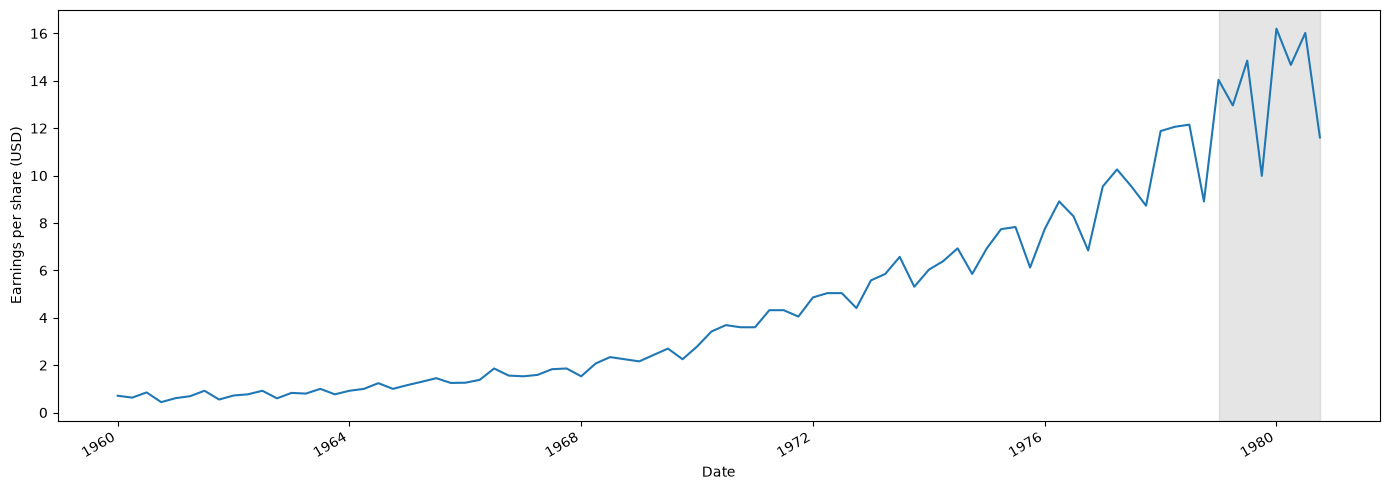

In [3]:
train = df.iloc[:-8].copy()
test = df.iloc[-8:].copy()
y = train["data"].values.astype(float)
n = len(y)

print(f"train: {len(train)} наблюдений ({train['date'].min():%Y-%m}…{train['date'].max():%Y-%m})")
print(f"test:  {len(test)} наблюдений ({test['date'].min():%Y-%m}…{test['date'].max():%Y-%m})")

fig, ax = plt.subplots()
ax.plot(df["date"], df["data"])
ax.set_xlabel("Date")
ax.set_ylabel("Earnings per share (USD)")
ax.axvspan(test["date"].iloc[0], test["date"].iloc[-1], color="#808080", alpha=0.2)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 0.2. Функция для графика с интервалом

Во всех разделах ниже нам нужен один и тот же график: история, точечный прогноз и закрашенная
полоса (или две — 80% и 95%) вокруг него. Как и в ноутбуке 1, выносим это в функцию, чтобы не
копировать код для каждого метода и каждого фреймворка.

In [4]:
def plot_forecast_pi(train, test, point, lo, hi, title, lo2=None, hi2=None):
    fig, ax = plt.subplots()
    ax.plot(train["date"], train["data"], "g-.", label="Train")
    ax.plot(test["date"], test["data"], "b-", label="Test")
    ax.plot(test["date"], point, "r--o", ms=4, label="Прогноз")
    if lo2 is not None:
        ax.fill_between(test["date"], lo2, hi2, color="r", alpha=0.15, label="80%")
    ax.fill_between(test["date"], lo, hi, color="r", alpha=0.30, label="95%")
    ax.set_xlabel("Date")
    ax.set_ylabel("Earnings per share (USD)")
    ax.legend(loc=2)
    ax.set_title(title)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

---
# 1. Интервал прогноза в предположении нормальности

Если ошибки прогноза распределены нормально, то $100(1-\alpha)\%$ интервал имеет вид

$$
\hat y_{n+h|n} \pm z_{1-\alpha/2}\,\hat\sigma_h,
$$

где $\hat\sigma_h$ — стандартное отклонение прогноза на $h$ шагов, а $z_{1-\alpha/2}$ — квантиль
стандартного нормального распределения.

In [5]:
for lvl in [80, 90, 95, 99]:
    alpha_lvl = 1 - lvl / 100
    z_lvl = stats.norm.ppf(1 - alpha_lvl / 2)
    print(f"level={lvl:>3}%   z = {z_lvl:.3f}")

level= 80%   z = 1.282
level= 90%   z = 1.645
level= 95%   z = 1.960
level= 99%   z = 2.576


## 1.1. Оценка $\hat\sigma$ по остаткам одношагового прогноза

При $h=1$ величину $\hat\sigma_1$ оценивают прямо по **остаткам** одношагового прогноза:
$\hat\sigma^2 = \frac{1}{n-K}\sum_{t} e_t^2$, где $K$ — число параметров, оценённых моделью
(для naive и seasonal naive $K=0$, для drift $K=1$ — угол наклона). Возьмём наивный прогноз
$\hat y_{t|t-1}=y_{t-1}$, тогда остатки — это первые разности $e_t = y_t - y_{t-1}$.

n = 76,  σ̂ (по остаткам naive) = 0.825


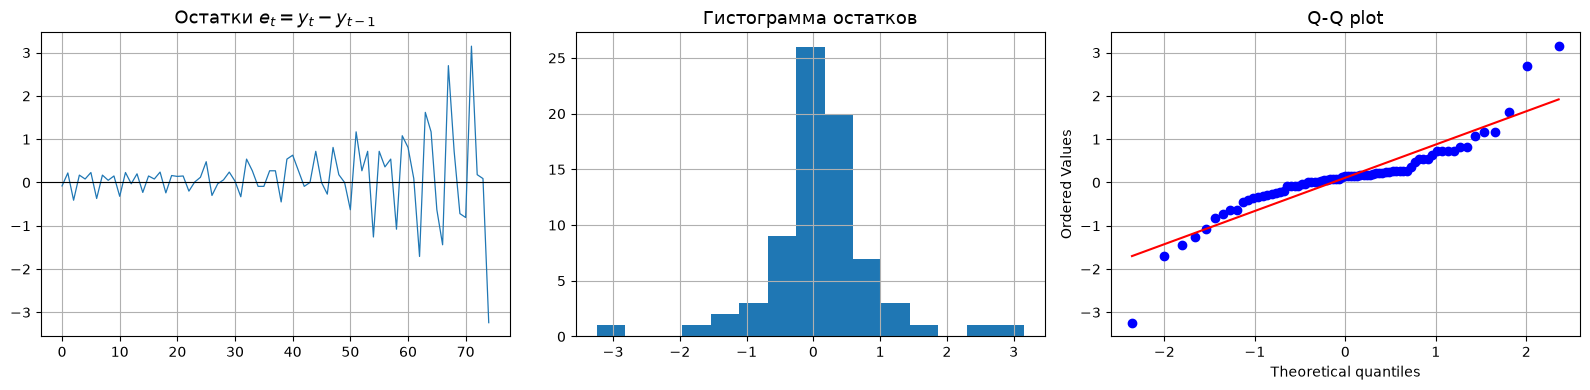

In [6]:
resid = y[1:] - y[:-1]  # остатки наивного прогноза
sigma_hat = np.sqrt(np.mean(resid**2))  # σ̂ = sqrt( mean(e_t²) ),  K=0 для naive
print(f"n = {n},  σ̂ (по остаткам naive) = {sigma_hat:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(resid, lw=0.9)
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_title("Остатки $e_t=y_t-y_{t-1}$", fontsize=13)
axes[0].grid()
axes[1].hist(resid, bins=15)
axes[1].set_title("Гистограмма остатков", fontsize=13)
axes[1].grid()
stats.probplot(resid, plot=axes[2])
axes[2].set_title("Q-Q plot", fontsize=13)
axes[2].grid()
plt.tight_layout()
plt.show()

🔍 На Q-Q plot видно, что точки на краях отклоняются от прямой — остатки не идеально нормальны.
У ряда J&J дисперсия квартальной прибыли растёт вместе с уровнем ряда (типичная картина для
растущих показателей компании), из-за чего остатки скошены и разброс неоднороден во времени.
Это ровно то, что лечится **преобразованием таргета** (ноутбук 2, Box–Cox/log): на
преобразованном ряде интервал в предположении нормальности работает честнее. Сейчас же мы
намеренно строим интервал «как есть», чтобы увидеть формулы и API — а к качеству вернёмся
в разделе 3, когда будем измерять Coverage Rate на тесте.

## 1.2. Наивный прогноз с интервалом

Для наивного метода дисперсия прогноза растёт линейно с горизонтом (вывод — в разделе 2):
$\hat\sigma_h = \hat\sigma\sqrt{h}$. Построим прогноз на 8 кварталов вперёд с 95%-м интервалом
«руками».

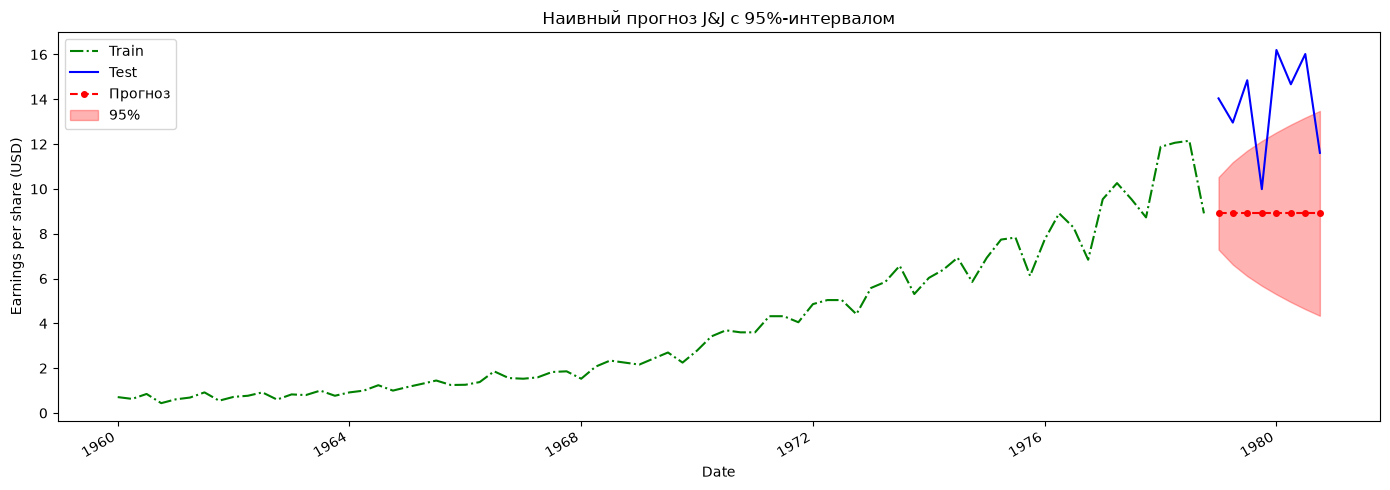

,h,прогноз,Lo 95,Hi 95
0,1,8.91,7.29,10.53
1,2,8.91,6.62,11.20
2,3,8.91,6.11,11.71
3,4,8.91,5.68,12.14
4,5,8.91,5.30,12.52
5,6,8.91,4.95,12.87
6,7,8.91,4.63,13.19
7,8,8.91,4.34,13.48


In [7]:
h = 8
hh = np.arange(1, h + 1)
z95 = stats.norm.ppf(0.975)

point_naive = np.full(h, y[-1])  # наивный прогноз: последнее значение
sigma_h_naive_vals = sigma_hat * np.sqrt(hh)  # σ_h = σ̂·√h
lo = point_naive - z95 * sigma_h_naive_vals
hi = point_naive + z95 * sigma_h_naive_vals

plot_forecast_pi(train, test, point_naive, lo, hi, "Наивный прогноз J&J с 95%-интервалом")

pd.DataFrame({"h": hh, "прогноз": point_naive.round(2), "Lo 95": lo.round(2), "Hi 95": hi.round(2)})

Интервал **расширяется** по мере роста горизонта — чем дальше в будущее, тем больше
неопределённость. Это фундаментальное свойство многошаговых прогнозов.

🔍 **Важная оговорка на будущее.** Эта формула учитывает только дисперсию остатков одношагового
прогноза. Она **не** учитывает неопределённость в оценке параметров модели и тем более
неопределённость в выборе самой модели (а вдруг наивный метод — не лучший?). Поэтому на практике
реальные интервалы почти всегда оказываются **шире**, чем говорит формула — а построенные по ней
интервалы систематически слишком узкие. Единственный способ это проверить — сравнить с фактическим
покрытием на отложенных данных (раздел 3).

---
# 2. Аналитические формулы для четырёх базовых методов

В предположении, что остатки некоррелированы и нормальны с дисперсией $\hat\sigma^2$,
распределение прогноза для базовых методов известно в явном виде (FPP3, Table 5.2):

$$
\begin{aligned}
\textbf{Mean:}\quad & \hat\sigma_h = \hat\sigma\sqrt{1+\tfrac1n}\\
\textbf{Naive:}\quad & \hat\sigma_h = \hat\sigma\sqrt{h}\\
\textbf{Seasonal naive:}\quad & \hat\sigma_h = \hat\sigma\sqrt{k+1},\quad k=\Big\lfloor \tfrac{h-1}{m}\Big\rfloor\\
\textbf{Drift:}\quad & \hat\sigma_h = \hat\sigma\sqrt{h\Big(1+\tfrac{h}{n-1}\Big)}
\end{aligned}
$$

где $\hat\sigma^2=\frac1n\sum_{t=1}^{n}e_t^2$ — дисперсия остатков **одношагового** прогноза
соответствующего метода, $m$ — длина сезона. Множитель при $\hat\sigma$ и определяет, как быстро
расширяется интервал с горизонтом $h$.

🔍 Формула drift здесь — из FPP3 (третье издание учебника), и именно её реализуют `statsforecast`,
`sktime` и `etna`. Если вам встретится вариант $\hat\sigma\sqrt{h(n+h)/n}$ из более старых
источников (FPP2) — численно он близок, но не совпадает; при сверке с библиотеками ниже
используем формулу FPP3, иначе цифры разойдутся сильнее, чем можно списать на округление.

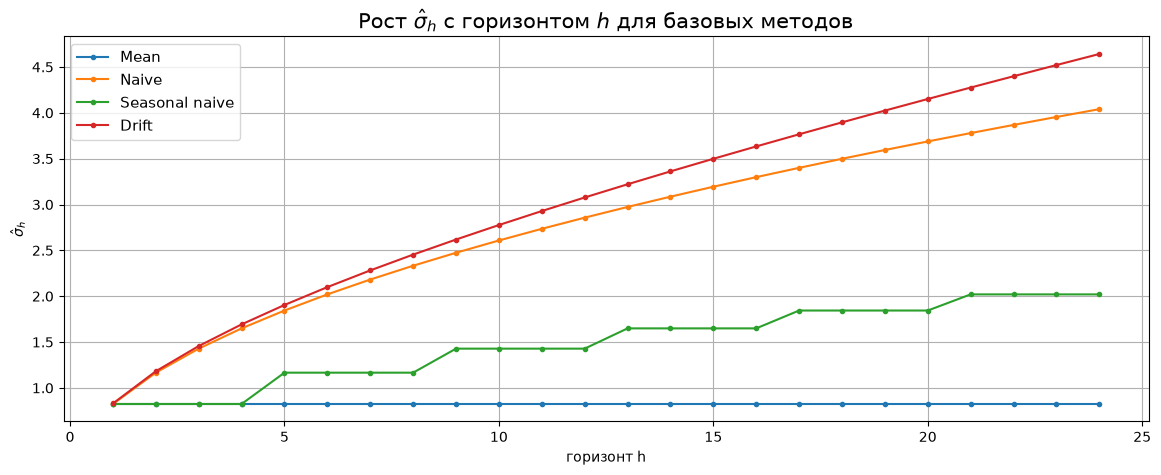

In [8]:
def sigma_h_mean(sigma, n, h, m=1):
    return sigma * np.sqrt(1 + 1 / n) * np.ones(h)


def sigma_h_naive(sigma, n, h, m=1):
    return sigma * np.sqrt(np.arange(1, h + 1))


def sigma_h_snaive(sigma, n, h, m):
    k = np.floor((np.arange(1, h + 1) - 1) / m)
    return sigma * np.sqrt(k + 1)


def sigma_h_drift(sigma, n, h, m=1):
    hh = np.arange(1, h + 1)
    return sigma * np.sqrt(hh * (1 + hh / (n - 1)))


H = 24
formulas = {
    "Mean": sigma_h_mean,
    "Naive": sigma_h_naive,
    "Seasonal naive": sigma_h_snaive,
    "Drift": sigma_h_drift,
}

fig, ax = plt.subplots()
for name, fn in formulas.items():
    ax.plot(np.arange(1, H + 1), fn(sigma_hat, n, H, 4), "-o", ms=3, label=name)
ax.set_title(r"Рост $\hat\sigma_h$ с горизонтом $h$ для базовых методов", fontsize=15)
ax.set_xlabel("горизонт h")
ax.set_ylabel(r"$\hat\sigma_h$")
ax.legend(fontsize=11)
ax.grid()
plt.show()

У **Mean** дисперсия почти не растёт — прогноз опирается на всю выборку и её среднее уже
довольно точно оценено. У **Seasonal naive** рост идёт ступеньками: внутри одного сезонного
цикла $\hat\sigma_h$ не меняется, а на границе цикла подскакивает. У **Naive** рост $\propto\sqrt h$
— интуиция простая: наивный $h$-шаговый прогноз равен $y_n$ плюс сумма $h$ будущих
(гипотетически независимых) одношаговых ошибок, а дисперсия суммы независимых слагаемых
складывается: $\mathrm{Var}=h\hat\sigma^2$. У **Drift** — быстрее всех, потому что к той же
сумме ошибок добавляется неопределённость в оценке наклона $\frac{y_n-y_1}{n-1}$, которая с
ростом $h$ входит в прогноз со всё большим весом.

## 2.1. Полный ручной интервал для всех четырёх методов

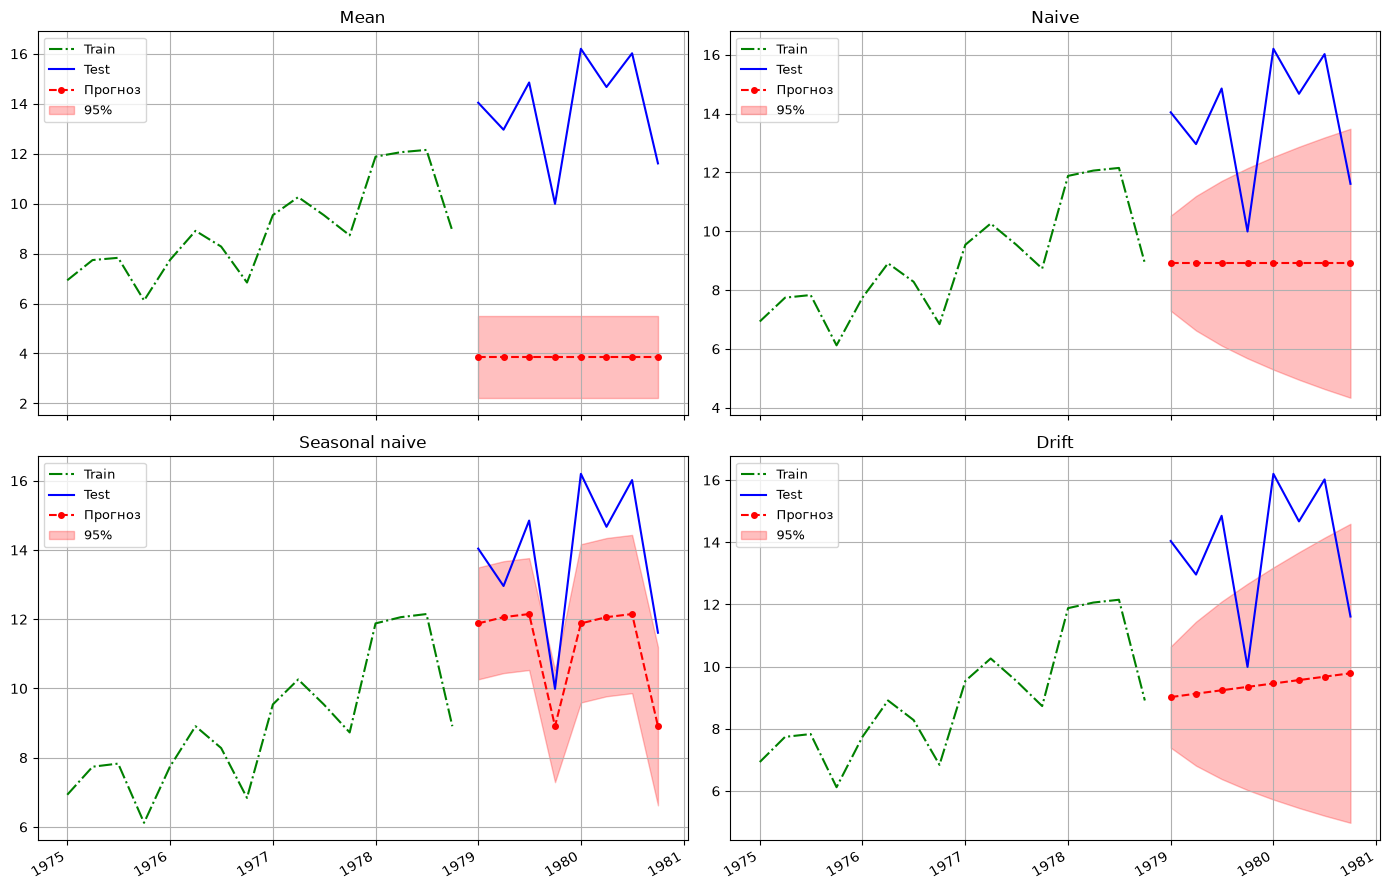

In [9]:
last, first = y[-1], y[0]
m = 4  # длина сезона у квартального ряда

point_mean = np.full(h, y.mean())
point_snaive = np.array([y[-m + (hi_ - 1) % m] for hi_ in hh])
slope = (last - first) / (n - 1)
point_drift = last + hh * slope

points = {
    "Mean": point_mean,
    "Naive": point_naive,
    "Seasonal naive": point_snaive,
    "Drift": point_drift,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for ax, (name, fn) in zip(axes.ravel(), formulas.items()):
    sig_h = fn(sigma_hat, n, h, m)
    pt = points[name]
    lo_m, hi_m = pt - z95 * sig_h, pt + z95 * sig_h
    ax.plot(train["date"].iloc[-16:], train["data"].iloc[-16:], "g-.", label="Train")
    ax.plot(test["date"], test["data"], "b-", label="Test")
    ax.plot(test["date"], pt, "r--o", ms=4, label="Прогноз")
    ax.fill_between(test["date"], lo_m, hi_m, color="r", alpha=0.25, label="95%")
    ax.set_title(name)
    ax.legend(fontsize=9)
    ax.grid()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

---
# 3. Метрики качества интервального прогноза: формулы руками

Точечные метрики (RMSE, MAE, …) не годятся для интервалов — нужны специальные меры. Разберём
пять, реализовав каждую «руками» на **тестовой** части ряда, а затем в разделе 4 посчитаем те же
числа через фреймворки и сверим.

In [10]:
y_true = test["data"].values.astype(float)
alpha = 0.05

# нормальный 95%-интервал наивного прогноза на тест (те же формулы, что в разделе 1-2)
sigma_h_test = sigma_hat * np.sqrt(hh)
L = point_naive - z95 * sigma_h_test  # нижняя граница
U = point_naive + z95 * sigma_h_test  # верхняя граница

## 3.1. Coverage Rate (CR) и Mean Interval Width (MIW)

$$
\mathrm{CR}=\frac1n\sum_t \mathbb{I}\{y_t\in[\ell_{\alpha,t},u_{\alpha,t}]\},
\qquad
\mathrm{MIW}=\frac1n\sum_t (u_{\alpha,t}-\ell_{\alpha,t}).
$$

**CR** — доля фактических значений, попавших в интервал (в идеале $\approx 1-\alpha$). **MIW** —
средняя ширина. Ни одна из них не работает в одиночку: тривиально расширив интервал до
$\pm\infty$, получим CR = 100%, но толку в таком прогнозе нет — поэтому обе метрики смотрят
вместе, как компромисс «покрытие ↔ ширина».

In [11]:
def coverage_rate(y, lo, hi):
    return np.mean((y >= lo) & (y <= hi))


def mean_interval_width(lo, hi):
    return np.mean(hi - lo)


print(f"Coverage Rate (цель {1 - alpha:.0%}): {coverage_rate(y_true, L, U):.1%}")
print(f"Mean Interval Width:               {mean_interval_width(L, U):.2f}")

Coverage Rate (цель 95%): 25.0%
Mean Interval Width:               6.59


## 3.2. Winkler Score

Winkler Score объединяет ширину и штраф за «промахи» мимо интервала $100(1-\alpha)\%$:

$$
W_t=
\begin{cases}
(u_{\alpha,t}-\ell_{\alpha,t}) + \dfrac{2}{\alpha}(\ell_{\alpha,t}-y_t), & y_t<\ell_{\alpha,t},\\[6pt]
(u_{\alpha,t}-\ell_{\alpha,t}), & \ell_{\alpha,t}\le y_t\le u_{\alpha,t},\\[6pt]
(u_{\alpha,t}-\ell_{\alpha,t}) + \dfrac{2}{\alpha}(y_t-u_{\alpha,t}), & y_t>u_{\alpha,t}.
\end{cases}
$$

Если наблюдение внутри интервала — штраф равен просто ширине. Если снаружи — добавляется штраф,
пропорциональный тому, насколько далеко значение вышло за границу. **Меньше — лучше.**

In [12]:
def winkler_score(y, lo, hi, alpha):
    width = hi - lo
    below, above = y < lo, y > hi
    w = width.copy().astype(float)
    w[below] += (2 / alpha) * (lo[below] - y[below])
    w[above] += (2 / alpha) * (y[above] - hi[above])
    return np.mean(w)


print(f"Winkler Score (95%): {winkler_score(y_true, L, U, alpha):.2f}")

Winkler Score (95%): 90.24


## 3.3. Quantile Score (pinball loss)

Интервал состоит из квантилей. Оценить один квантильный прогноз $f_{p,t}$ (уровня $p$) помогает
**Quantile Score**:

$$
Q_{p,t}=
\begin{cases}
2(1-p)\,(f_{p,t}-y_t), & y_t<f_{p,t},\\[4pt]
2p\,(y_t-f_{p,t}), & y_t\ge f_{p,t}.
\end{cases}
$$

Из-за формы графика её называют **pinball loss**. Множитель 2 часто опускают. Границы 95%-го
интервала — это квантили $p=0.025$ (нижняя) и $p=0.975$ (верхняя); усреднение pinball loss по
набору квантилей называют **MQLoss** (Multi-Quantile Loss) — с ней мы встретимся в `utilsforecast`.

In [13]:
def quantile_score(y, f, p):
    diff = f - y
    return np.mean(np.where(y < f, 2 * (1 - p) * diff, 2 * p * (-diff)))


qs_low = quantile_score(y_true, L, alpha / 2)  # p = 0.025
qs_high = quantile_score(y_true, U, 1 - alpha / 2)  # p = 0.975
print(f"Quantile Score, нижняя граница (p=0.025): {qs_low:.3f}")
print(f"Quantile Score, верхняя граница (p=0.975): {qs_high:.3f}")
print(f"среднее по двум границам (≈MQLoss):        {(qs_low + qs_high) / 2:.3f}")

Quantile Score, нижняя граница (p=0.025): 0.409
Quantile Score, верхняя граница (p=0.975): 4.103
среднее по двум границам (≈MQLoss):        2.256


## 3.4. CRPS

Часто интересно **всё распределение** прогноза, а не отдельные квантили. **Continuous Ranked
Probability Score** усредняет квантильные оценки по всем уровням $p$:

$$
\mathrm{CRPS}=\frac1n\sum_t \int_{-\infty}^{\infty}\big(F_t(x)-\mathbb{I}\{x\ge y_t\}\big)^2\,dx,
$$

где $F_t$ — функция распределения прогноза. CRPS выражается в единицах ряда и обобщает MAE на
вероятностные прогнозы. Для **нормального** прогноза $\mathcal N(\mu,\sigma)$ есть замкнутая
формула:

$$
\mathrm{CRPS}=\sigma\left[\omega\,(2\Phi(\omega)-1)+2\varphi(\omega)-\tfrac{1}{\sqrt\pi}\right],
\qquad \omega=\frac{y-\mu}{\sigma}.
$$

In [14]:
def crps_gaussian(y, mu, sigma):
    omega = (y - mu) / sigma
    return np.mean(
        sigma
        * (omega * (2 * stats.norm.cdf(omega) - 1) + 2 * stats.norm.pdf(omega) - 1 / np.sqrt(np.pi))
    )


crps_norm = crps_gaussian(y_true, point_naive, sigma_h_test)
print(f"CRPS (нормальный прогноз): {crps_norm:.3f}")

CRPS (нормальный прогноз): 4.034


## 3.5. Итоговая таблица: метрика и её место во фреймворках

Мы реализовали пять мер руками. Прежде чем идти во фреймворки, сразу зафиксируем, что где
искать — дальше будем сверять именно с этими названиями.

| метрика | руками | `utilsforecast.losses` | `sktime.performance_metrics` | `etna.metrics` |
|---|---|---|---|---|
| Coverage | `coverage_rate` | `coverage` | `EmpiricalCoverage` | `Coverage` |
| Width | `mean_interval_width` | — | `IntervalWidth` | `Width` |
| Winkler | `winkler_score` | — | — | — |
| Pinball / MQLoss | `quantile_score` | `quantile_loss`, `mqloss` | `PinballLoss` | — |
| CRPS | `crps_gaussian` | `scaled_crps` | `CRPS` | — |
| Calibration | — | `calibration` | `AUCalibration` | — |

🔍 Не у всех фреймворков есть все метрики. Winkler Score нет ни в `utilsforecast`, ни в `etna` —
это не недосмотр, просто в экосистеме Nixtla и ETNA её место занимают Coverage + Width по
отдельности, а в sktime похожая идея штрафа за промах называется `ConstraintViolation` и считается
немного иначе. CRPS у `utilsforecast` и `sktime` — тоже не одно и то же число: `scaled_crps` в
`utilsforecast` — это квантильная аппроксимация, нормированная на масштаб ряда (удобно сравнивать
ряды разного масштаба между собой), а `sktime.CRPS` считает CRPS по объекту-распределению из
`predict_proba` — цифры не обязаны совпадать, и это нормально.

---
# 4. Интервалы и метрики во фреймворках

Три библиотеки решают одну и ту же задачу — дать границы неопределённости вокруг точечного
прогноза — очень разными интерфейсами:

| | как попросить интервал | что возвращает | как считаются границы внутри |
|---|---|---|---|
| `statsforecast` | `sf.forecast(h, level=[80, 95])` | колонки `Model-lo-95`, `Model-hi-95` | `mean ± z·σ_h`, `σ_h` — та же аналитическая формула базового метода, что в разделе 2 |
| `sktime` | `predict_interval`, `predict_quantiles`, `predict_var`, `predict_proba` | MultiIndex-колонки / объект-распределение | `_predict_var` реализует ту же Table 5.2 (FPP3), что мы вывели руками |
| `etna` | обёртка `NaiveVariancePredictionIntervals(pipeline)` + `forecast(prediction_interval=True, ...)` | колонки `target_0.025`, `target_0.975` в `TSDataset` | дисперсия **эмпирическая**: из матрицы остатков k-fold бэктеста, аналитических формул нет |

Разберём каждый по очереди на нашем наивном прогнозе J&J.

## 4.1. `statsforecast`

В `statsforecast` интервал запрашивается ровно так же, как в ноутбуке 1 запрашивался
точечный прогноз — через параметр `level`, добавленный в `forecast`/`predict`.

In [15]:
from statsforecast import StatsForecast
from statsforecast.models import HistoricAverage, Naive, RandomWalkWithDrift, SeasonalNaive

sf_train = train.rename(columns={"date": "ds", "data": "y"})
sf_train["unique_id"] = "jj"
sf_test = test.rename(columns={"date": "ds", "data": "y"})
sf_test["unique_id"] = "jj"

sf = StatsForecast(
    models=[HistoricAverage(), Naive(), SeasonalNaive(season_length=4), RandomWalkWithDrift()],
    freq="QS",
)
sf_fc = sf.forecast(df=sf_train, h=h, level=[80, 95])
sf_fc.head()

/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-packages/joblib/_multiprocessing_helpers.py:44: UserWarning: [Errno 1] Operation not permitted.  joblib will operate in serial mode
  warnings.warn("%s.  joblib will operate in serial mode" % (e,))


,unique_id,ds,HistoricAverage,HistoricAverage-lo-80,HistoricAverage-lo-95,HistoricAverage-hi-80,HistoricAverage-hi-95,Naive,Naive-lo-80,Naive-lo-95,...,SeasonalNaive,SeasonalNaive-lo-80,SeasonalNaive-lo-95,SeasonalNaive-hi-80,SeasonalNaive-hi-95,RWD,RWD-lo-80,RWD-lo-95,RWD-hi-80,RWD-hi-95
0,jj,1979-01-01,3.853158,-0.344339,-2.56636,8.050655,10.272675,8.91,7.853199,7.293763,...,11.88,10.827279,10.270002,12.932721,13.489998,9.019333,7.964902,7.406720,10.073764,10.631946
1,jj,1979-04-01,3.853158,-0.344339,-2.56636,8.050655,10.272675,8.91,7.415458,6.624295,...,12.06,11.007279,10.450002,13.112721,13.669998,9.128667,7.627698,6.833133,10.629636,11.424201
2,jj,1979-07-01,3.853158,-0.344339,-2.56636,8.050655,10.272675,8.91,7.079567,6.110595,...,12.15,11.097279,10.540002,13.202721,13.759998,9.238000,7.387797,6.408359,11.088203,12.067641
3,jj,1979-10-01,3.853158,-0.344339,-2.56636,8.050655,10.272675,8.91,6.796398,5.677525,...,8.91,7.857279,7.300002,9.962721,10.519998,9.347333,7.197252,6.059068,11.497415,12.635599
4,jj,1980-01-01,3.853158,-0.344339,-2.56636,8.050655,10.272675,8.91,6.546922,5.295983,...,11.88,10.391228,9.603119,13.368772,14.156881,9.456667,7.037636,5.757079,11.875697,13.156255


🔍 Обратите внимание на имена колонок: `{Model}-lo-{level}` и `{Model}-hi-{level}`. Модель
`Naive` внутри `statsforecast` использует ту же формулу $\hat\sigma\sqrt h$, что мы выписали в
разделе 2 — сверим числа.

In [16]:
sf_naive_lo95 = sf_fc["Naive-lo-95"].values
sf_naive_hi95 = sf_fc["Naive-hi-95"].values

pd.DataFrame(
    {
        "h": hh,
        "Lo95 (руками)": lo.round(3),
        "Lo95 (statsforecast)": sf_naive_lo95.round(3),
        "Hi95 (руками)": hi.round(3),
        "Hi95 (statsforecast)": sf_naive_hi95.round(3),
    }
)

,h,Lo95 (руками),Lo95 (statsforecast),Hi95 (руками),Hi95 (statsforecast)
0,1,7.294,7.294,10.526,10.526
1,2,6.624,6.624,11.196,11.196
2,3,6.111,6.111,11.709,11.709
3,4,5.678,5.678,12.142,12.142
4,5,5.296,5.296,12.524,12.524
5,6,4.951,4.951,12.869,12.869
6,7,4.634,4.634,13.186,13.186
7,8,4.339,4.339,13.481,13.481


Границы совпадают почти точно — небольшое расхождение объясняется деталями оценки $\hat\sigma$
(в `statsforecast._calculate_sigma` она считается чуть иначе, с поправкой на число остатков).
То же самое сработает и для `RandomWalkWithDrift`: внутри он вычисляет
`sigmah = sigma * sqrt(steps * (1 + steps/(n-1)))` — это ровно формула drift из раздела 2.

Построим «веер» из двух уровней доверия (80% и 95%) — стандартную визуализацию неопределённости.

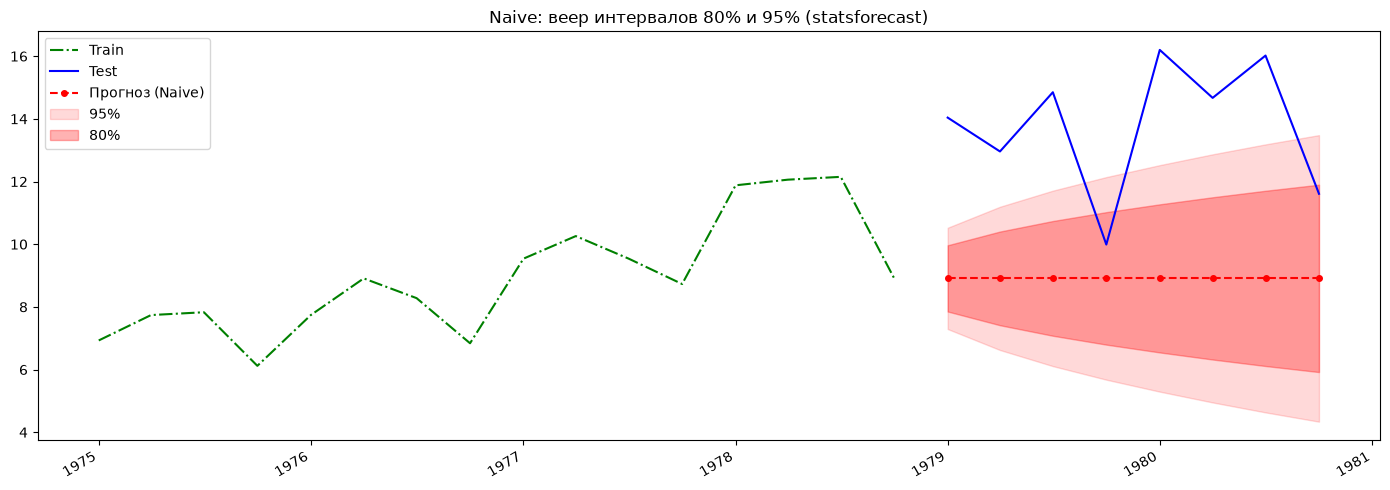

In [17]:
fig, ax = plt.subplots()
ax.plot(train["date"].iloc[-16:], train["data"].iloc[-16:], "g-.", label="Train")
ax.plot(test["date"], test["data"], "b-", label="Test")
ax.plot(test["date"], sf_fc["Naive"], "r--o", ms=4, label="Прогноз (Naive)")
ax.fill_between(
    test["date"], sf_fc["Naive-lo-95"], sf_fc["Naive-hi-95"], color="r", alpha=0.15, label="95%"
)
ax.fill_between(
    test["date"], sf_fc["Naive-lo-80"], sf_fc["Naive-hi-80"], color="r", alpha=0.30, label="80%"
)
ax.legend(loc=2)
ax.set_title("Naive: веер интервалов 80% и 95% (statsforecast)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Метрики через `utilsforecast`

`statsforecast` не считает метрики сам — это работа соседнего пакета `utilsforecast` (та же
логика «графики и метрики живут не в главном пакете», что мы видели в ноутбуке 2 семинара 1).
Сначала подклеим фактические значения теста к прогнозу — так же, как это делает бэктест внутри
фреймворков.

In [18]:
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import coverage, mqloss, scaled_crps

sf_merged = sf_fc.merge(sf_test[["unique_id", "ds", "y"]], on=["unique_id", "ds"])

models = ["HistoricAverage", "Naive", "SeasonalNaive", "RWD"]
metrics_uf = evaluate(sf_merged, metrics=[coverage, mqloss, scaled_crps], models=models, level=[95])
metrics_uf

,unique_id,metric,HistoricAverage,Naive,SeasonalNaive,RWD
0,jj,coverage_level95,0.125000,0.250000,0.250000,0.250000
1,jj,mqloss,1.938067,1.127952,0.425616,0.941187
2,jj,scaled_crps,0.281032,0.163560,0.061717,0.136478


🔍 Главный источник ошибок при первом использовании: `coverage` принимает `models` **списком**
имён моделей и сам достраивает названия колонок `{model}-lo-{level}`/`{model}-hi-{level}`. А
`mqloss` и `scaled_crps`, если вызывать их напрямую (не через `evaluate`), ждут `models` как
**словарь** `{"Naive": ["Naive-lo-95", "Naive-hi-95"]}` плюс массив `quantiles=[0.025, 0.975]` —
`evaluate` берёт эту рутину на себя по параметру `level`, поэтому в учебном коде удобнее вызывать
метрики именно через `evaluate`, а не по отдельности.

Winkler Score в `utilsforecast` нет — посчитаем его так же руками, как в разделе 3, подставив
границы `statsforecast`.

In [19]:
for model in models:
    w = winkler_score(
        sf_test["y"].values, sf_fc[f"{model}-lo-95"].values, sf_fc[f"{model}-hi-95"].values, 0.05
    )
    print(f"{model:>15}: Winkler(95%) = {w:.2f}")

HistoricAverage: Winkler(95%) = 155.05
          Naive: Winkler(95%) = 90.24
  SeasonalNaive: Winkler(95%) = 34.05
            RWD: Winkler(95%) = 75.29


## 4.2. `sktime`

У прогнозаторов `sktime` есть не один, а четыре вложенных уровня вероятностного API —
от интервала до полного распределения:

In [20]:
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.naive import NaiveForecaster

y_ser = pd.Series(y)
fh = ForecastingHorizon(hh, is_relative=True)
f_sk = NaiveForecaster(strategy="last", sp=1).fit(y_ser)

pi_sk = f_sk.predict_interval(fh, coverage=0.95)  # 1. интервал: (lower, upper)
q_sk = f_sk.predict_quantiles(fh, alpha=[0.025, 0.975])  # 2. квантили: те же границы, др. язык
var_sk = f_sk.predict_var(fh)  # 3. дисперсия прогноза
proba_sk = f_sk.predict_proba(fh)  # 4. объект-распределение целиком

pi_sk.head()

/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-packages/sktime/forecasting/base/_base.py:1040: UserWarning: Forecasters' predict_proba requires skpro to be present in the python environment, for distribution objects to represent distributional forecasts. To silence this message, ensure skpro is installed in the environment when calling forecasters' predict_proba.
  warn(msg, obj=self, stacklevel=2)


0           
        0.95           
       lower      upper
76  7.293763  10.526237
77  6.624295  11.195705
78  6.110595  11.709405
79  5.677525  12.142475
80  5.295983  12.524017

🔍 Результат — не обычный `DataFrame`, а таблица с **MultiIndex**-колонками: `predict_interval`
возвращает уровни `(имя_переменной, coverage, "lower"/"upper")`, `predict_quantiles` — `(имя,
alpha)`. Это первое, обо что спотыкаются новички: `pi_sk["lower"]` не сработает, нужно
`pi_sk.iloc[:, 0]` или обращение по полному кортежу `pi_sk[(0, 0.95, "lower")]`. Четыре метода
согласованы между собой: `predict_interval` и `predict_quantiles(alpha=[0.025, 0.975])` для
уровня 95% дают одни и те же числа, `predict_var` — их дисперсию, а `predict_proba` — полноценный
объект распределения (в данном случае нормального), из которого первые три и получаются.

In [21]:
lo_sk = pi_sk.iloc[:, 0].values
hi_sk = pi_sk.iloc[:, 1].values

pd.DataFrame(
    {
        "h": hh,
        "Lo95 (руками)": lo.round(3),
        "Lo95 (sktime)": lo_sk.round(3),
        "Hi95 (руками)": hi.round(3),
        "Hi95 (sktime)": hi_sk.round(3),
        "σ_h² (predict_var)": var_sk.iloc[:, 0].values.round(3),
    }
)

,h,Lo95 (руками),Lo95 (sktime),Hi95 (руками),Hi95 (sktime),σ_h² (predict_var)
0,1,7.294,7.294,10.526,10.526,0.68
1,2,6.624,6.624,11.196,11.196,1.36
2,3,6.111,6.111,11.709,11.709,2.04
3,4,5.678,5.678,12.142,12.142,2.72
4,5,5.296,5.296,12.524,12.524,3.40
5,6,4.951,4.951,12.869,12.869,4.08
6,7,4.634,4.634,13.186,13.186,4.76
7,8,4.339,4.339,13.481,13.481,5.44


Границы совпадают почти точно: `NaiveForecaster._predict_var` реализует ту же формулу Table 5.2
из FPP3, что мы вывели руками в разделе 2 (в исходниках `sktime` так и написано — ссылка на
`otexts.com/fpp3/prediction-intervals.html`), только считает $\hat\sigma$ по остаткам fitted-
модели с чуть другой поправкой на степени свободы.

🔍 А что если модель **не умеет** считать интервалы сама? У всех прогнозаторов `sktime` есть флаг
`"capability:pred_int"` в `get_tag(...)`; если он `False`, обернуть модель в
`sktime.forecasting.naive.NaiveVariance(forecaster)` — она посчитает дисперсию прогноза по
остаткам k-fold бэктеста и добавит те же четыре метода `predict_*`. Тот же принцип «наивная
оценка дисперсии по бэктесту» мы увидим дальше у `etna`.

### Метрики через `sktime.performance_metrics.forecasting.probabilistic`

In [22]:
from sktime.performance_metrics.forecasting.probabilistic import (
    EmpiricalCoverage,
    IntervalWidth,
    PinballLoss,
)

y_true_ser = pd.Series(y_true, index=pd.RangeIndex(n, n + h))

pl = PinballLoss()
ec = EmpiricalCoverage()
iw = IntervalWidth()

print(f"PinballLoss:      {pl(y_true_ser, q_sk):.3f}")
print(f"EmpiricalCoverage: {ec(y_true_ser, pi_sk):.1%}")
print(f"IntervalWidth:     {iw(y_true_ser, pi_sk):.2f}")

PinballLoss:      1.128
EmpiricalCoverage: 25.0%
IntervalWidth:     6.59


`PinballLoss` принимает выход `predict_quantiles`, а `EmpiricalCoverage`/`IntervalWidth` — выход
`predict_interval`; названия классов прямо говорят, какую метрику раздела 3 они реализуют.
`sktime` умеет считать такие метрики и в кросс-валидации через
`sktime.forecasting.model_evaluation.evaluate(forecaster=..., cv=..., scoring=PinballLoss())` —
с этим вы встретитесь на занятии про валидацию.

## 4.3. `etna`

У `etna` нет отдельного «режима с интервалом» внутри модели — вместо этого весь **пайплайн**
оборачивается в объект из `etna.prediction_intervals`, который умеет считать неопределённость
для любой модели снизу.

In [23]:
from etna.datasets import TSDataset
from etna.metrics import Coverage as EtnaCoverage
from etna.metrics import Width as EtnaWidth
from etna.models import NaiveModel
from etna.pipeline import Pipeline
from etna.prediction_intervals import NaiveVariancePredictionIntervals

etna_long = df.rename(columns={"date": "timestamp", "data": "target"})
etna_long["segment"] = "jj"

ts = TSDataset(
    TSDataset.to_dataset(etna_long), freq="QS-OCT"
)  # метка квартала у pandas не совпадает с "QS", но месяцы те же
train_ts, test_ts = ts.train_test_split(test_size=h)

pipeline = Pipeline(model=NaiveModel(lag=1), horizon=h)
pipeline = NaiveVariancePredictionIntervals(pipeline=pipeline)
pipeline.fit(train_ts)

etna_forecast = pipeline.forecast(prediction_interval=True, quantiles=(0.025, 0.975), n_folds=3)
etna_forecast.to_pandas()

/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-packages/etna/settings.py:35: UserWarning: etna[torch] is not available, to install it, run `pip install etna[torch]`
  warnings.warn("etna[torch] is not available, to install it, run `pip install etna[torch]`")
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-packages/etna/settings.py:49: UserWarning: etna[chronos] is not available, to install it, run `pip install etna[chronos]`
  warnings.warn("etna[chronos] is not available, to install it, run `pip install etna[chronos]`")
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-packages/etna/settings.py:64: UserWarning: etna[timesfm] is not available, to install it, run `pip install etna[timesfm]`
  warnings.warn("etna[timesfm] is not available, to install it, run `pip install etna[timesfm]`")
/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-pack

/Users/a.p.chikov/PycharmProjects/Временные ряды/Семинары/2/.venv/lib/python3.11/site-packages/etna/pipeline/base.py:786: UserWarning: joblib backend 'multiprocessing' is not available on your system, falling back to threading.
  with Parallel(n_jobs=n_jobs, **joblib_params) as parallel:
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: 

segment        jj                          
feature    target target_0.025 target_0.975
timestamp                                  
1979-01-01   8.91     5.374723    12.445277
1979-04-01   8.91     4.166928    13.653072
1979-07-01   8.91     5.054745    12.765255
1979-10-01   8.91     5.919915    11.900085
1980-01-01   8.91     3.139911    14.680089
1980-04-01   8.91     1.731714    16.088286
1980-07-01   8.91     0.804702    17.015298
1980-10-01   8.91     2.796891    15.023109

🔍 Ключевое отличие от `statsforecast`/`sktime`: у `NaiveVariancePredictionIntervals` **нет**
аналитической формулы Table 5.2. Внутри она делает k-fold бэктест (`n_folds` окон), на каждом
окне считает остатки модели на весь горизонт, оценивает дисперсию по этой матрице остатков и
только затем строит нормальный квантиль вокруг неё (`prediction_intervals/naive_variance.py`).
Поэтому границы `etna` **не обязаны** совпадать с ручными — это принципиально другой источник
оценки $\hat\sigma_h$, эмпирический, а не формульный. У такого подхода есть цена: на коротких
рядах не хватит наблюдений на `n_folds` окон бэктеста нужной длины горизонта — тогда `n_folds`
приходится уменьшать.

Метрики `Coverage`/`Width` берут имена колонок с границами прямо из объекта прогноза:

In [24]:
lower_name, upper_name = etna_forecast.prediction_intervals_names
etna_cov = EtnaCoverage(lower_name=lower_name, upper_name=upper_name)(test_ts, etna_forecast)
etna_width = EtnaWidth(lower_name=lower_name, upper_name=upper_name)(test_ts, etna_forecast)
print(f"Coverage (etna): {etna_cov['jj']:.1%}")
print(f"Width (etna):    {etna_width['jj']:.2f}")

Coverage (etna): 62.5%
Width (etna):    10.57


Кроме `NaiveVariancePredictionIntervals`, в `etna.prediction_intervals` есть ещё
`EmpiricalPredictionIntervals` (квантили самих остатков, без нормального допущения) и
`ConformalPredictionIntervals` — к ним мы вернёмся в разделе 5.

## 4.4. Сводное сравнение по методам

Соберём Coverage Rate, Mean Interval Width и Winkler Score для наших четырёх базовых методов
(нормальный 95%-интервал, границы `statsforecast`) в одну таблицу.

In [25]:
def row(name, lo_, hi_):
    return {
        "метод": name,
        "Coverage (цель 95%)": f"{coverage_rate(sf_test['y'].values, lo_, hi_):.1%}",
        "MIW": round(mean_interval_width(lo_, hi_), 2),
        "Winkler": round(winkler_score(sf_test["y"].values, lo_, hi_, 0.05), 2),
    }


pd.DataFrame([row(m, sf_fc[f"{m}-lo-95"].values, sf_fc[f"{m}-hi-95"].values) for m in models])

,метод,Coverage (цель 95%),MIW,Winkler
0,HistoricAverage,12.5%,12.84,155.05
1,Naive,25.0%,6.59,90.24
2,SeasonalNaive,25.0%,3.89,34.05
3,RWD,25.0%,6.75,75.29


Здесь наглядно виден компромисс **покрытие ↔ ширина**: метод может достигать нужного покрытия
только за счёт более широких (и потому менее информативных) интервалов, и Winkler Score
штрафует за оба перекоса сразу. 🔍 Восемь точек теста — это всё ещё очень шумная оценка Coverage
Rate (шаг $12.5\%$): один провал или один случайный успех сильно двигает число. Честная проверка
интервалов делается на нескольких окнах кросс-валидации, а не на одном тесте — этим мы займёмся
на Семинаре 2, когда будем разбирать схемы валидации для временных рядов.

---
# 5. А что дальше: бутстреп и конформное прогнозирование

Нормальные формулы опираются на предположение о том, что остатки независимы и нормально
распределены — как мы видели в разделе 1, для J&J это предположение выполняется не идеально.
Есть два способа строить PI, не полагаясь на нормальность:

- **Бутстреп** — насэмплировать множество будущих траекторий из исторических остатков и взять
  эмпирические квантили на каждом шаге горизонта;
- **Конформное прогнозирование** — откалибровать ширину интервала по ошибкам модели на
  нескольких прошлых окнах, с формальной гарантией покрытия при минимальных предположениях.

Разберём их подробно на отдельном занятии. Здесь — только координаты в API, чтобы вы знали, куда
смотреть:

| | бутстреп | конформное прогнозирование |
|---|---|---|
| `statsforecast` | `prediction_intervals=` у модели (бутстреп остатков) | `statsforecast.utils.ConformalIntervals`, передаётся в модель как `prediction_intervals=` |
| `sktime` | — | `sktime.forecasting.conformal.ConformalIntervals` (обёртка над прогнозатором) |
| `etna` | `etna.prediction_intervals.EmpiricalPredictionIntervals` | `etna.prediction_intervals.ConformalPredictionIntervals` |

---
# Выводы

- **Интервал прогноза** сообщает неопределённость точечного прогноза; при нормальных остатках
  он равен $\hat y_{n+h}\pm z_{1-\alpha/2}\,\hat\sigma_h$, где $\hat\sigma_1$ оценивается по
  остаткам одношагового прогноза.
- Для базовых методов известны **аналитические формулы** дисперсии (FPP3, Table 5.2); интервал
  закономерно **расширяется с горизонтом** — быстрее всего у drift и naive, почти не растёт у mean.
- Качество интервалов измеряют специальными метриками: **Coverage Rate** и **Mean Interval
  Width** (компромисс покрытие↔ширина), **Winkler Score** (ширина + штраф за промахи),
  **Quantile Score / MQLoss** (отдельные квантили) и **CRPS** (всё распределение целиком).
- `statsforecast`, `sktime` и `etna` дают интервалы и метрики через разные интерфейсы, но
  `statsforecast` и `sktime` под капотом считают одну и ту же аналитическую формулу, а `etna`
  всегда оценивает дисперсию эмпирически, по бэктесту — поэтому её границы не обязаны совпадать
  с ручными.
- Реальные интервалы почти всегда **слишком узкие**, потому что формула не учитывает
  неопределённость в параметрах и в выборе модели. Всегда проверяйте покрытие на отложенных
  данных — и лучше на нескольких окнах кросс-валидации, а не на одном тесте.
- Если остатки не нормальны или ряд нестационарен — на помощь приходят бутстреп и конформное
  прогнозирование; разберём их на отдельном занятии.